# Εργασία Εξαμήνου — Μέρος Α
## Προεπεξεργασία, Embeddings και Εξερευνητική Ανάλυση

**Ονόματα & ΑΜ:**
- Γιώργος Δέλγας , 1115202200036
- Γιώργος Παλαιοκώστας , 1115202200126

In [22]:
%pip install wordcloud nltk vaderSentiment matplotlib scikit-learn pandas numpy --quiet    

Note: you may need to restart the kernel to use updated packages.


## 0. Εισαγωγή Βιβλιοθηκών

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tarfile
import bz2
import os
import nltk

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

from wordcloud import WordCloud
from collections import Counter

from gensim.models import Word2Vec
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


# Για ομοιόμορφα γραφήματα
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Ορισμός του random seed για αναπαραγωγιμότητα
SEED = 42

print('Βιβλιοθήκες φορτώθηκαν επιτυχώς.')

Βιβλιοθήκες φορτώθηκαν επιτυχώς.


---
## 1. Συλλογή Δεδομένων (Data Collection)

Φορτώνουμε τα 5 αρχεία του dataset και τα συνδέουμε μέσω του κοινού πεδίου `id` (Song ID).  
Στόχος είναι να κρατήσουμε μόνο τα τραγούδια που έχουν δεδομένα και στις 3 κύριες πηγές: **Genre, Audio (MFCC), Lyrics**.

### 1.1 Φόρτωση Genres — Εύρεση Top-5

Κάθε τραγούδι μπορεί να ανήκει σε περισσότερα από ένα genres (comma-separated).  
Κρατάμε τη λίστα των genres αφαιρόντας duplicates , βρίσκουμε τα 5 πιο συχνά και φιλτράρουμε το dataset.

In [24]:
df_genres = pd.read_csv('id_genres.csv', sep='\t')
print(f'Γραμμές: {len(df_genres)}')
df_genres.head()

Γραμμές: 109269


,id,genres
0,0009fFIM1eYThaPg,pop
1,0010xmHR6UICBOYT,underground hip hop
2,002Jyd0vN4HyCpqL,"hard rock,rock,classic rock"
3,006TYKNjNxWjfKjy,"symphonic metal,power metal,symphonic power metal"
4,007LIJOPQ4Sb98qV,"post-punk,new wave"


In [25]:
# Κρατάμε ΟΛΑ τα genres ανά τραγούδι, χωρίς duplicates
df_genres['genre_list_unique'] = df_genres['genres'].str.split(',').apply(
    lambda x: list(dict.fromkeys(g.strip() for g in x))
)

# Flat λίστα genres για να βρούμε τα Top-5
all_genres_flat = df_genres.explode('genre_list_unique')['genre_list_unique']
top5_genres = all_genres_flat.value_counts().head(5).index.tolist()
print('Top-5 Genres:', top5_genres)

# Φιλτράρισμα σε song-level dataframe: κρατάμε τα τραγούδια που έχουν τουλάχιστον ένα Top-5 genre
df_genres_filtered = df_genres[['id', 'genre_list_unique']].copy()
df_genres_filtered = df_genres_filtered[df_genres_filtered['genre_list_unique'].apply(
    lambda genres: any(genre in top5_genres for genre in genres)
)].copy()

# Exploded view μόνο για genre counts / EDA όταν χρειάζεται
df_genres_exploded = df_genres_filtered.explode('genre_list_unique').copy()
df_genres_exploded.rename(columns={'genre_list_unique': 'genre'}, inplace=True)

print(f"Τραγούδια στα Top-5 Genres: {df_genres_filtered['id'].count()}")
print(f'Γραμμές στο exploded id-genre table: {len(df_genres_exploded)}')
df_genres_exploded['genre'].value_counts()

Top-5 Genres: ['rock', 'pop', 'electronic', 'alternative rock', 'indie rock']
Τραγούδια στα Top-5 Genres: 56100
Γραμμές στο exploded id-genre table: 134266


genre
rock                   23949
pop                    20267
electronic             11739
alternative rock        7591
indie rock              7353
                       ...  
wrestling                  1
alternative hip hop        1
afrikaans                  1
bassline                   1
batida                     1
Name: count, Length: 538, dtype: int64

### 1.2 Φόρτωση Audio Features (MFCC Stats)

Το αρχείο είναι TSV συμπιεσμένο με bz2. Περιέχει 13 MFCC μέσους όρους και τον πίνακα συνδιακύμανσης (flattened upper triangle), συνολικά ~104 features ανά τραγούδι.  
Φιλτράρουμε μόνο τα IDs που μας ενδιαφέρουν για εξοικονόμηση μνήμης.

In [26]:
target_ids = set(df_genres_filtered['id'])

chunks = []
with bz2.open('id_mfcc_stats.tsv.bz2', 'rt') as f:
    for chunk in pd.read_csv(f, sep='\t', chunksize=1000):
        filtered = chunk[chunk['id'].isin(target_ids)]
        if not filtered.empty:
            chunks.append(filtered)

df_mfcc = pd.concat(chunks, ignore_index=True)
print(f'MFCC rows: {len(df_mfcc)}, columns: {len(df_mfcc.columns)}')
df_mfcc.head(2)

MFCC rows: 56100, columns: 105


,id,MFCC000,MFCC001,MFCC002,MFCC003,MFCC004,MFCC005,MFCC006,MFCC007,MFCC008,...,cov_9_9,cov_9_10,cov_9_11,cov_9_12,cov_10_10,cov_10_11,cov_10_12,cov_11_11,cov_11_12,cov_12_12
0,9EPCgcAlXdgiFsx4,20.640961,-5.828413,-6.140859,2.526664,-1.409552,2.681575,-2.989035,6.298501,3.528709,...,154.790424,21.799839,-15.056062,-19.218533,109.895439,26.262901,-4.037570,120.298222,18.571392,84.858156
1,9epP1yOXfLKlkR3S,24.351542,-16.611490,-10.792922,0.983246,-4.003687,-0.180248,-1.510487,-0.663130,2.915891,...,57.688839,20.511395,3.479626,-1.560816,63.036257,26.379835,2.551358,55.188890,18.194372,52.472903


### 1.3 Φόρτωση Tags

Τα tags είναι User-Generated Content — δίνουν την «ανθρώπινη» ερμηνεία κάθε τραγουδιού.

In [27]:
df_tags_raw = pd.read_csv('id_tags.csv', sep='\t')
df_tags = df_tags_raw[df_tags_raw['id'].isin(target_ids)][['id', 'tags']].copy()
print(f'Tags rows: {len(df_tags)}')
df_tags.head()

Tags rows: 56100


,id,tags
0,0009fFIM1eYThaPg,"pop,british,female vocalists,dance,cheryl cole"
2,002Jyd0vN4HyCpqL,"hard rock,rock,classic rock,american artist"
5,00CH4HJdxQQQbJfu,"indie rock,experimental,indie,chillout,shoegaz..."
6,00DZ3XCAQb2FdCc6,"ambient,mellow,instrumental,easy listening,ele..."
8,00IeldeA9ijZOL0P,"pop,bollywood,one world,disney"


### 1.4 Φόρτωση Lyrics από tar.gz

Το αρχείο `processed_lyrics.tar.gz` περιέχει ~109k αρχεία κειμένου, ένα ανά τραγούδι (όνομα αρχείου = `{id}.txt`).  
Κάνουμε iterate στο tar και διαβάζουμε **μόνο** τα αρχεία που αντιστοιχούν στα IDs μας.

In [28]:
lyrics_dict = {}

with tarfile.open('processed_lyrics.tar.gz', 'r:gz') as tar:
    for member in tar.getmembers():
        # Εξαγωγή song ID από το όνομα αρχείου (π.χ. processed_lyrics/ABCD1234.txt)
        filename = os.path.basename(member.name)
        if not filename.endswith('.txt'):
            continue
        song_id = filename.replace('.txt', '')
        if song_id in target_ids:
            f = tar.extractfile(member)
            if f:
                lyrics_dict[song_id] = f.read().decode('utf-8', errors='ignore')

df_lyrics = pd.DataFrame(list(lyrics_dict.items()), columns=['id', 'lyrics'])
print(f'Lyrics rows: {len(df_lyrics)}')
df_lyrics.head(2)

Lyrics rows: 56100


,id,lyrics
0,9jbSytob9XRzwvB6,deep feel heart burn deep insid yearn know com...
1,Njp6JPM8vitbhVJU,noth hurt like pain someon love noth gain prep...


### 1.5 Merge — Intersection

Κρατάμε μόνο τα τραγούδια που έχουν δεδομένα **και στα τρία**: Genre, Audio, Lyrics.

In [29]:
df_merged = df_genres_filtered \
    .merge(df_mfcc, on='id') \
    .merge(df_lyrics, on='id') \
    .merge(df_tags, on='id', how='left')  # tags προαιρετικά

print(f'Τελικό dataset: {df_merged.shape[0]} τραγούδια, {df_merged.shape[1]} στήλες')
print('Κατανομή genres:')
print(df_genres_exploded['genre'].value_counts().head(10))
df_merged.head(3)

Τελικό dataset: 56100 τραγούδια, 108 στήλες
Κατανομή genres:
genre
rock                 23949
pop                  20267
electronic           11739
alternative rock      7591
indie rock            7353
classic rock          4334
hard rock             2518
singer-songwriter     2268
indie pop             2165
experimental          2008
Name: count, dtype: int64


,id,genre_list_unique,MFCC000,MFCC001,MFCC002,MFCC003,MFCC004,MFCC005,MFCC006,MFCC007,...,cov_9_11,cov_9_12,cov_10_10,cov_10_11,cov_10_12,cov_11_11,cov_11_12,cov_12_12,lyrics,tags
0,0009fFIM1eYThaPg,[pop],23.622419,-14.435319,-7.964634,-4.066164,-0.910089,-0.460288,4.683222,2.938227,...,2.908798,-6.870236,116.923098,21.549632,0.300939,110.923613,24.561615,96.538287,sunni day get nowher hide cloud sky pretend ge...,"pop,british,female vocalists,dance,cheryl cole"
1,002Jyd0vN4HyCpqL,"[hard rock, rock, classic rock]",22.909323,-7.674675,-19.895458,1.233454,-20.380484,-3.534497,-20.514660,-4.578214,...,23.668015,15.582351,95.043195,42.135654,15.282257,120.657505,73.015982,122.500418,goer phone freiburg say willi do quit job hitl...,"hard rock,rock,classic rock,american artist"
2,00CH4HJdxQQQbJfu,"[indie rock, experimental, shoegaze]",23.436211,-7.816750,-12.406812,11.062952,-9.058584,-1.206321,-5.282046,-3.253329,...,-36.455772,-2.586953,80.042622,23.692883,-14.386593,92.754345,20.962145,84.711864,crimin walk room ask live way think could woul...,"indie rock,experimental,indie,chillout,shoegaz..."


---
## 2. Εξόρυξη Χαρακτηριστικών & Embeddings (Feature Extraction)

Δημιουργούμε δύο ξεχωριστούς πίνακες χαρακτηριστικών:
- **Audio Embeddings**: Μέσω PCA στα MFCC features
- **Text Embeddings**: Μέσω Word2Vec στους στίχους

### 2.1 Audio Embeddings — PCA

Τα MFCC stats είναι υψηλής διάστασης (~104 features) και θορυβώδη. Εφαρμόζουμε:
1. **Κανονικοποίηση** (StandardScaler) — απαραίτητο πριν PCA
2. **PCA** με 95% διατήρηση variance — μειώνει δραστικά τις διαστάσεις

In [30]:
# Στήλες MFCC (όλες εκτός id, text/tags και λιστών genres)
mfcc_cols = [
    c for c in df_merged.columns
    if c not in ['id', 'lyrics', 'tags', 'genre_list_unique']
]
print(f'MFCC feature columns: {len(mfcc_cols)}')

X_audio = df_merged[mfcc_cols].values.astype(float)

# Κανονικοποίηση
scaler = StandardScaler()
X_audio_scaled = scaler.fit_transform(X_audio)

# PCA — κράτα 95% variance
pca = PCA(n_components=0.95, random_state=SEED)
X_audio_pca = pca.fit_transform(X_audio_scaled)

print(f'Αρχικές διαστάσεις: {X_audio.shape[1]}')
print(f'Μετά PCA (95% variance): {X_audio_pca.shape[1]}')
print(f'Explained variance ratio (πρώτες 5 components): {pca.explained_variance_ratio_[:5].round(3)}')

MFCC feature columns: 104
Αρχικές διαστάσεις: 104
Μετά PCA (95% variance): 81
Explained variance ratio (πρώτες 5 components): [0.186 0.063 0.039 0.033 0.03 ]


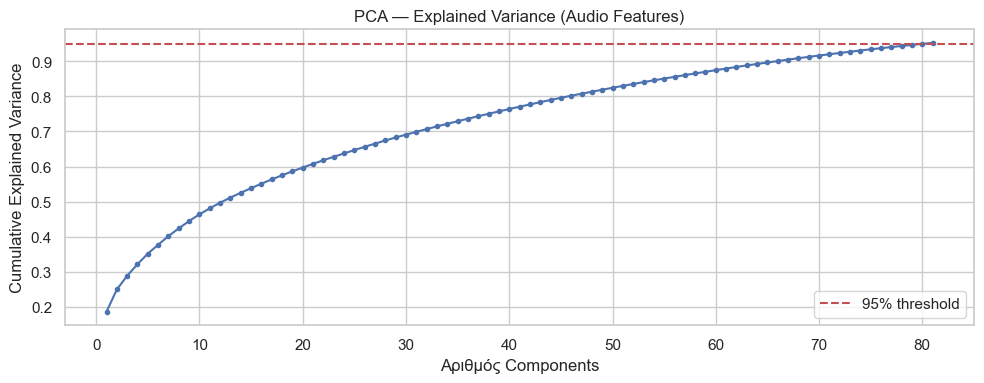

In [31]:
# Γράφημα explained variance (Scree Plot)
cumvar = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o', markersize=3)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.xlabel('Αριθμός Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Explained Variance (Audio Features)')
plt.legend()
plt.tight_layout()
plt.show()

### 2.2 Text Embeddings — Word2Vec

Εκπαιδεύουμε ένα μοντέλο Word2Vec πάνω στο corpus των στίχων.  
Για κάθε τραγούδι, το embedding είναι ο **μέσος όρος** των word vectors όλων των λέξεων του.

In [32]:
# Tokenization — οι στίχοι είναι ήδη προεπεξεργασμένοι (space-separated tokens)
sentences = [lyric.split() for lyric in df_merged['lyrics'].fillna('')]

# Εκπαίδευση Word2Vec
w2v_model = Word2Vec(
    sentences,
    vector_size=100,   # διάσταση embedding
    window=5,          # context window
    min_count=3,       # αγνόησε λέξεις που εμφανίζονται < 3 φορές
    workers=1,
    seed=SEED,
    epochs=10
)

print(f'Vocabulary size: {len(w2v_model.wv)}')
print(f'Vector size: {w2v_model.vector_size}')

Vocabulary size: 23803
Vector size: 100


In [33]:
def song_to_vector(tokens, model):
    """Μέσος όρος word vectors για ένα τραγούδι."""
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    return np.zeros(model.vector_size)

X_text = np.array([
    song_to_vector(tokens, w2v_model)
    for tokens in sentences
])

print(f'Text embeddings shape: {X_text.shape}')

Text embeddings shape: (56100, 100)


---
## 3. Οπτικοποίηση και Ανάλυση (EDA)

Εξερευνούμε τα δεδομένα μέσω γραφημάτων για να κατανοήσουμε τη δομή τους πριν το modeling.

### 3.1 Κατανομή Genres (Bar Chart)

Πρώτη ματιά στο πόσα τραγούδια έχουμε ανά genre.

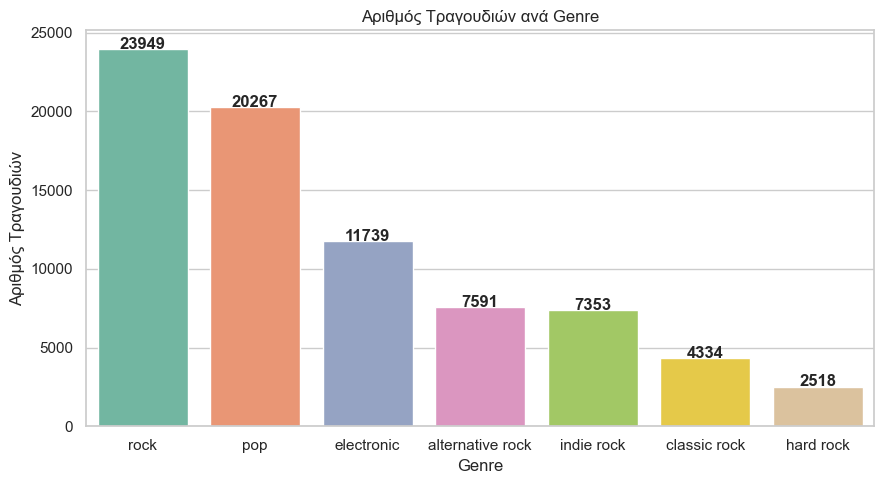

In [34]:
genre_counts = df_genres_exploded['genre'].value_counts().head(7)

plt.figure(figsize=(9, 5))
sns.barplot(x=genre_counts.index, y=genre_counts.values, hue=genre_counts.index, palette='Set2', legend=False)
plt.title('Αριθμός Τραγουδιών ανά Genre')
plt.xlabel('Genre')
plt.ylabel('Αριθμός Τραγουδιών')
for i, v in enumerate(genre_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 Top-10 Tags ανά Genre (Top-5 Genres)



Τα tags είναι User-Generated Content. Παρακάτω βλέπουμε τα 10 πιο συχνά tags για τα **Top-5 genres**.

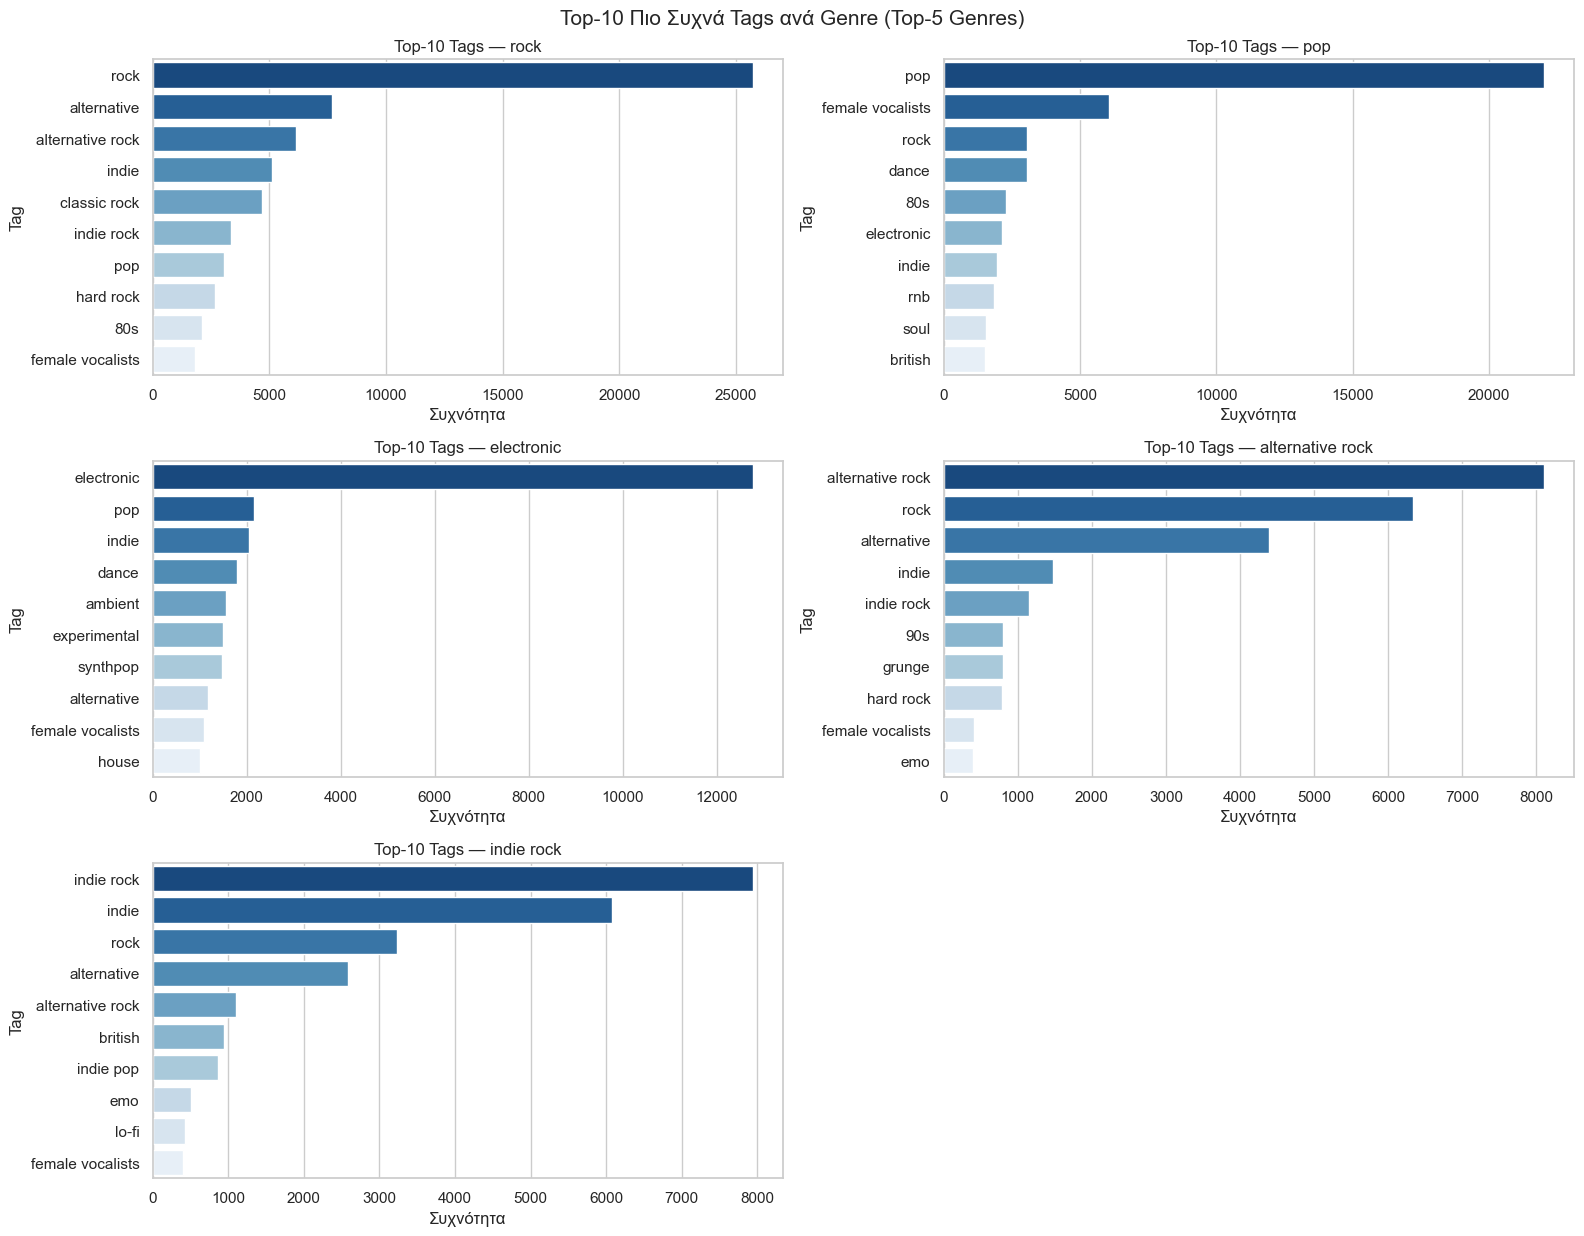

In [ ]:
# Top-10 tags ανά genre μόνο για τα Top-5 genres

available_genres = set(df_genres_exploded['genre'].dropna().unique())
genres_for_tags = [g for g in top5_genres if g in available_genres]



n_genres = len(genres_for_tags)
ncols = 2
nrows = (n_genres + ncols - 1) // ncols



fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.2 * nrows), squeeze=False)
axes = axes.flatten()



for i, genre in enumerate(genres_for_tags):

    genre_ids = set(df_genres_exploded.loc[df_genres_exploded['genre'] == genre, 'id'])
    genre_tags_series = df_merged.loc[df_merged['id'].isin(genre_ids), 'tags'].dropna()
    genre_tags = []

    for tags_str in genre_tags_series:

        genre_tags.extend([t.strip() for t in tags_str.split(',') if t.strip()])


    ax = axes[i]

    if genre_tags:

        tag_counts = Counter(genre_tags)
        top10 = tag_counts.most_common(10)
        labels, values = zip(*top10)

        sns.barplot(

            x=list(values),
            y=list(labels),
            hue=list(labels),
            palette='Blues_r',
            orient='h',
            dodge=False,
            legend=False,
            ax=ax

        )

        ax.set_title(f'Top-10 Tags — {genre}', fontsize=12)
        ax.set_xlabel('Συχνότητα')
        ax.set_ylabel('Tag')

    else:

        ax.text(0.5, 0.5, 'No tags available', ha='center', va='center', fontsize=11)
        ax.set_title(f'Top-10 Tags — {genre}', fontsize=12)
        ax.axis('off')



for j in range(i + 1, len(axes)):

    axes[j].axis('off')


plt.suptitle('Top-10 Πιο Συχνά Tags ανά Genre (Top-5 Genres)', fontsize=15)
plt.tight_layout()
plt.show()

Το αποτέλεσμα δείχνει ότι σε κάθε ένα από τα Top-5 genres υπάρχει ένας πολύ ισχυρός “genre πυρήνας” στα tags: το ίδιο το genre (π.χ. rock, pop, electronic, alternative rock, indie rock) εμφανίζεται με μεγάλη διαφορά από τα υπόλοιπα. Αυτό σημαίνει ότι τα tags έχουν υψηλή διακριτική πληροφορία για τη βασική κατηγορία.



Παράλληλα, οι επόμενες θέσεις σε κάθε γράφημα αποκαλύπτουν σημαντική επικάλυψη μεταξύ συγγενικών ειδών (π.χ. rock ↔ alternative ↔ indie), καθώς και περιγραφικά tags όπως female vocalists ή dance. Άρα τα tags είναι χρήσιμα για ταξινόμηση, αλλά αποτυπώνουν και την υβριδικότητα της μουσικής ταυτότητας, όχι μόνο καθαρές και απομονωμένες κλάσεις.

### 3.3 Word Clouds ανά Genre

Επιλέγουμε τα 2 πιο διαφορετικά genres και δημιουργούμε Word Cloud από τα tags τους.  
Τα word clouds αποκαλύπτουν την «ταυτότητα» κάθε genre μέσα από τη γλώσσα των χρηστών.

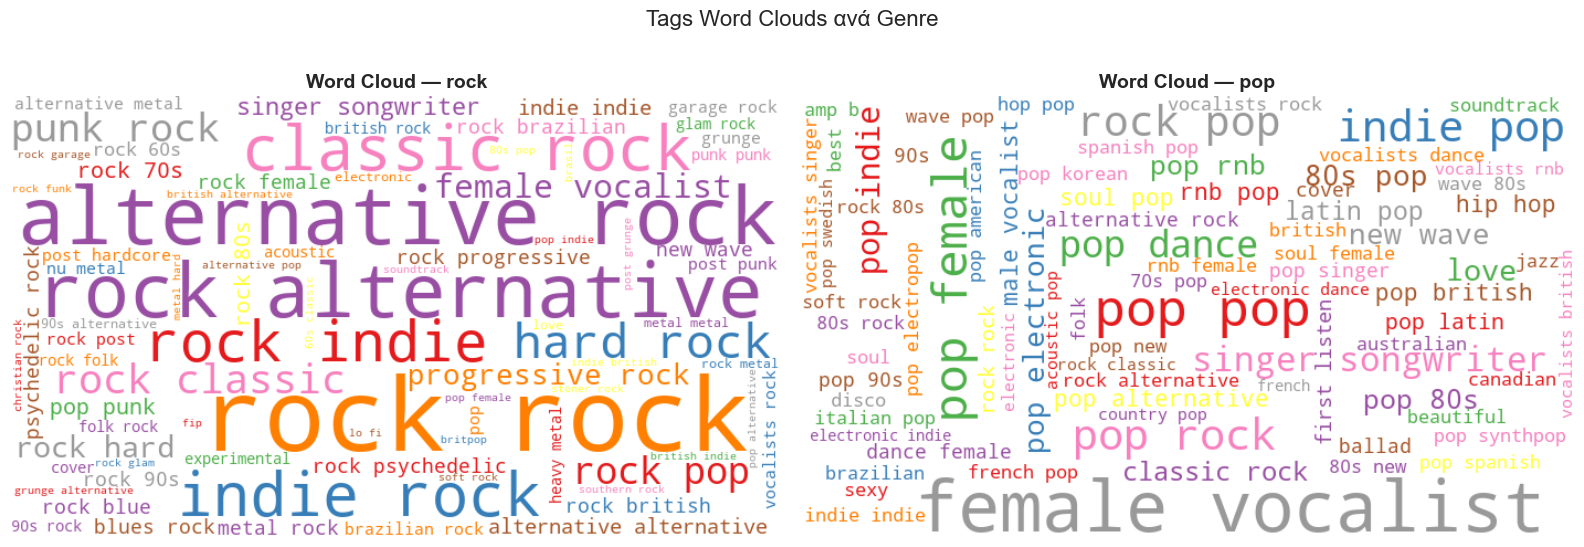

In [36]:
# Επιλογή 2 genres για σύγκριση 
genre_pair = [top5_genres[0], top5_genres[1]]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, genre in zip(axes, genre_pair):
    genre_tags = []
    mask = df_merged['genre_list_unique'].apply(lambda genres: genre in genres) & df_merged['tags'].notna()
    for tags_str in df_merged.loc[mask, 'tags']:
        genre_tags.extend([t.strip() for t in tags_str.split(',')])
    
    text = ' '.join(genre_tags)
    wc = WordCloud(width=700, height=400, background_color='white',
                   colormap='Set1', max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Word Cloud — {genre}', fontsize=14, fontweight='bold')
    ax.axis('off')

plt.suptitle('Tags Word Clouds ανά Genre', fontsize=16)
plt.tight_layout()
plt.show()

Στο Word Cloud του rock κυριαρχούν όροι όπως rock, alternative rock, indie rock, classic rock, hard rock, punk rock, κάτι που δείχνει ότι η ταυτότητα του genre είναι πιο “υποειδοκεντρική” και κιθαριστική, με έμφαση σε στιλιστικές αποχρώσεις του ίδιου πυρήνα. Η συχνή εμφάνιση πολλών παραλλαγών του “rock” υποδηλώνει ότι οι ακροατές περιγράφουν αυτά τα τραγούδια κυρίως με genre-specific labels.

Στο Word Cloud του pop κυριαρχούν όροι όπως female vocalist, pop, indie pop, pop rock, dance, electronic, singer songwriter, που δείχνουν πιο “υβριδική” ταυτότητα: συνδυασμό φωνητικής περσόνας, εμπορικού ύφους και επιρροών από γειτονικά genres. Δηλαδή, το pop φαίνεται να περιγράφεται λιγότερο με αυστηρό genre πυρήνα και περισσότερο με χαρακτηριστικά ύφους/ερμηνείας.

Συνολικά, τα word clouds δείχνουν ότι το rock εμφανίζεται πιο συνεκτικό ως genre οικογένεια, ενώ το pop πιο διασυνδεδεμένο με άλλα στυλ και με έμφαση σε περιγραφικά tags του performer.

### 3.4 Ποικιλία Genres ανά Τραγούδι

Πολλά τραγούδια δεν κατατάσσονται αποκλειστικά σε ένα genre — αντιθέτως "πάλλονται" μεταξύ ειδών.  
Το παρακάτω διάγραμμα δείχνει πόσα τραγούδια ανήκουν σε 1, 2, 3, ... διαφορετικά genres (χωρίς duplicates).  
Χρησιμοποιούμε το **πλήρες** `id_genres.csv` (όχι μόνο τα Top-5 filtered) για να έχουμε πλήρη εικόνα.

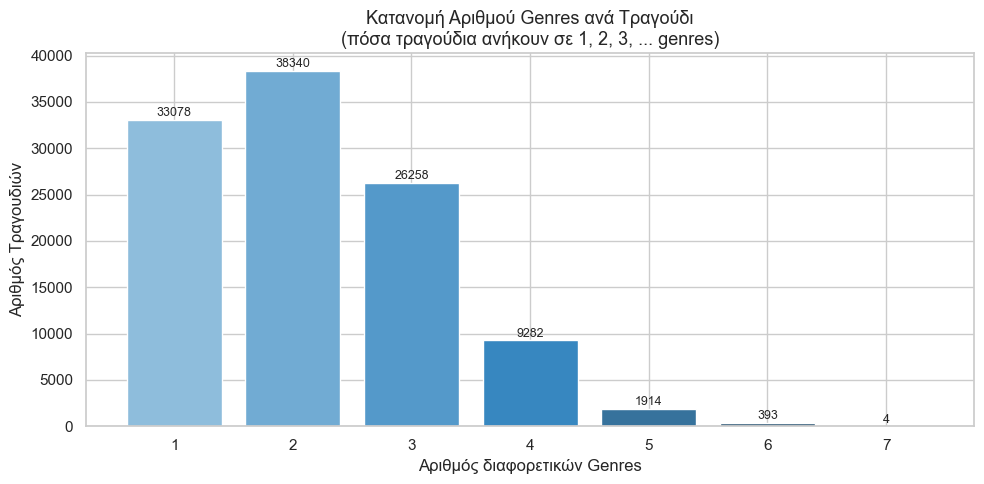

Τραγούδια με μόνο 1 genre: 33078 (30.3%)
Τραγούδια με 2 genres:    38340 (35.1%)
Τραγούδια με 3 genres:    26258 (24.0%)
Τραγούδια με 4 genres:    9282 (8.5%)
Τραγούδια με 5+ genres:   2311 (2.1%)


In [37]:
# Πλήθος μοναδικών genres ανά τραγούδι (χωρίς duplicates)
genre_variety = df_genres['genre_list_unique'].apply(len)

# Ομαδοποίηση: 1, 2, ..., 9, 10+
bins = genre_variety.clip(upper=10)
counts = bins.value_counts().sort_index()
labels = [str(i) if i < 10 else '10+' for i in counts.index]

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, counts.values, color=sns.color_palette('Blues_d', len(labels)), edgecolor='white')
plt.title('Κατανομή Αριθμού Genres ανά Τραγούδι\n(πόσα τραγούδια ανήκουν σε 1, 2, 3, ... genres)', fontsize=13)
plt.xlabel('Αριθμός διαφορετικών Genres')
plt.ylabel('Αριθμός Τραγουδιών')
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

only_one = (genre_variety == 1).sum()
multi_2 = (genre_variety == 2).sum()
multi_3 = (genre_variety == 3).sum()
multi_4 = (genre_variety == 4).sum()
multi_5 = (genre_variety >= 5).sum()
print(f'Τραγούδια με μόνο 1 genre: {only_one} ({only_one/len(genre_variety)*100:.1f}%)')
print(f'Τραγούδια με 2 genres:    {multi_2} ({multi_2/len(genre_variety)*100:.1f}%)')
print(f'Τραγούδια με 3 genres:    {multi_3} ({multi_3/len(genre_variety)*100:.1f}%)')
print(f'Τραγούδια με 4 genres:    {multi_4} ({multi_4/len(genre_variety)*100:.1f}%)')
print(f'Τραγούδια με 5+ genres:   {multi_5} ({multi_5/len(genre_variety)*100:.1f}%)')

Το διάγραμμα δείχνει καθαρά ότι τα περισσότερα τραγούδια δεν είναι “καθαρά” μονο-genre. Συγκεκριμένα, μόνο 33,078 τραγούδια (περίπου 30.3%) ανήκουν σε ένα μόνο genre, ενώ η πλειονότητα, δηλαδή 76,191 τραγούδια (περίπου 69.7%), ανήκει σε 2 ή περισσότερα genres. Η μεγαλύτερη συγκέντρωση εμφανίζεται στις κατηγορίες με 2 genres (38,340) και 3 genres (26,258), κάτι που επιβεβαιώνει ότι η μουσική ταυτότητα των τραγουδιών είναι συχνά υβριδική.

Αυτό έχει άμεση επίπτωση στη δυσκολία της ταξινόμησης: όταν ένα τραγούδι “μοιράζεται” χαρακτηριστικά από περισσότερα είδη, τα όρια μεταξύ των κλάσεων γίνονται ασαφή και αυξάνεται η επικάλυψη. Επομένως, η ταξινόμηση genre δεν είναι απλό πρόβλημα με αυστηρά διαχωρισμένες κατηγορίες, αλλά πρόβλημα με φυσική ασάφεια, όπου τα single-label μοντέλα έχουν εγγενείς περιορισμούς. Για αυτό και οι προσεγγίσεις που αξιοποιούν περισσότερη πληροφορία (π.χ. multimodal ή multi-label λογική) μπορούν να αποδώσουν πιο ρεαλιστικά.

### 3.5 Top-N Genres στο Πλήρες Dataset

Το αντίστροφο ερώτημα: αντί να δούμε πόσα genres έχει κάθε τραγούδι, βλέπουμε **πόσα τραγούδια έχει κάθε genre** στο σύνολο του dataset.  
Χρησιμοποιούμε μοναδικά genres ανά τραγούδι (αφαίρεση duplicates) για σωστή καταμέτρηση.

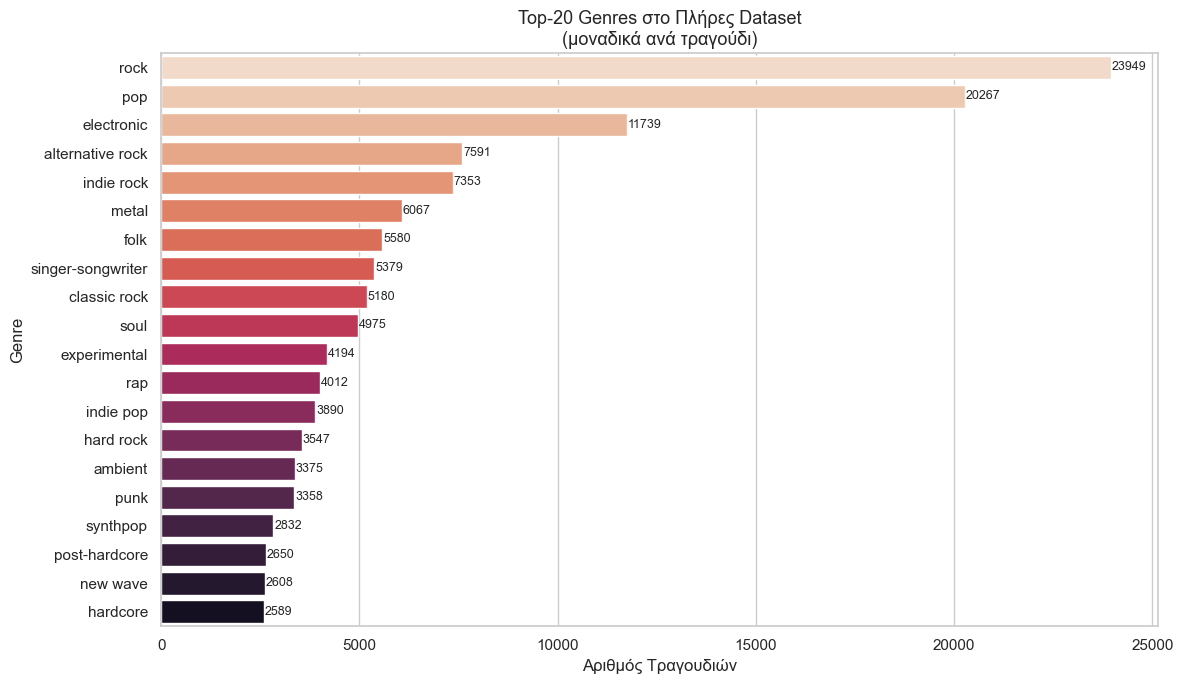

In [38]:
# Top-N genres μετρώντας μοναδικά genres ανά τραγούδι (χωρίς duplicates)
all_genres_flat = df_genres.explode('genre_list_unique')['genre_list_unique']
top20 = all_genres_flat.value_counts().head(20)

plt.figure(figsize=(12, 7))
sns.barplot(x=top20.values, y=top20.index, hue=top20.index, palette='rocket_r', orient='h', legend=False)
plt.title('Top-20 Genres στο Πλήρες Dataset\n(μοναδικά ανά τραγούδι)', fontsize=13)
plt.xlabel('Αριθμός Τραγουδιών')
plt.ylabel('Genre')
for i, v in enumerate(top20.values):
    plt.text(v + 20, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

Στο αντίστροφο διάγραμμα φαίνεται καθαρά ότι κυριαρχούν τα rock (23,949) και pop (20,267), με αισθητή απόσταση από το τρίτο genre electronic (11,739). Από εκεί και κάτω υπάρχει απότομη πτώση (π.χ. alternative rock 7,591, indie rock 7,353, metal 6,067), ενώ τα genres στο κάτω μέρος του Top-20 κινούνται κοντά στις 2.6k–3.0k εμφανίσεις.

Αυτό δείχνει ότι το dataset είναι ανισόρροπο ως προς τις κλάσεις: λίγα genres έχουν πολύ μεγάλη εκπροσώπηση, ενώ αρκετά άλλα έχουν σημαντικά μικρότερο πλήθος τραγουδιών. Η ανισορροπία αυτή επηρεάζει την ταξινόμηση, γιατί τα μοντέλα τείνουν να “ευνοούν” τις συχνές κλάσεις και να αποδίδουν χειρότερα στις λιγότερο συχνές. Συνεπώς, στην αξιολόγηση χρειάζονται metrics που δεν κρύβουν αυτή τη διαφορά (π.χ. macro μέσοι όροι) και προσεκτική ερμηνεία των αποτελεσμάτων ανά genre.

### 3.6 Κατανομή Μεγέθους Στίχων

Εξετάζουμε πόσο "πλούσια" σε λέξεις είναι τα τραγούδια:
- **Πλήθος λέξεων** και **χαρακτήρων** ανά τραγούδι
- Μετά αφαίρεση **stopwords** (the, a, is, ...) → πόσες ουσιαστικές λέξεις απομένουν

Τα histograms κόβονται στο 99ο percentile για να αποφύγουμε ακραίες τιμές.

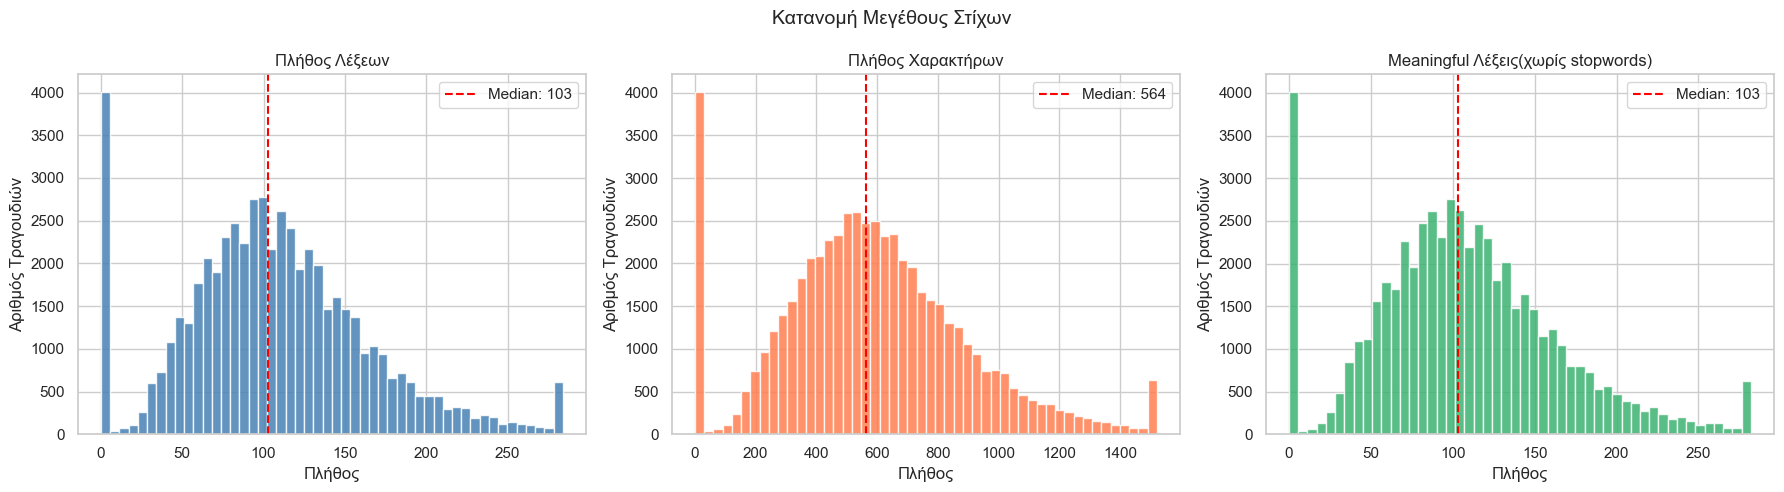

       word_count  char_count  meaningful_words
count     56100.0     56100.0           56100.0
mean        107.6       585.7             107.1
std          63.3       329.6              61.1
min           0.0         0.0               0.0
25%          70.0       386.0              70.0
50%         103.0       564.0             103.0
75%         140.0       764.0             139.0
max        2255.0     11293.0            2255.0


In [39]:
nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))

# Υπολογισμός στατιστικών στίχων
df_merged['word_count'] = df_merged['lyrics'].fillna('').apply(lambda x: len(x.split()))
df_merged['char_count'] = df_merged['lyrics'].fillna('').apply(len)
df_merged['meaningful_words'] = df_merged['lyrics'].fillna('').apply(
    lambda x: len([w for w in x.split() if w.lower() not in stop_words])
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title, color in zip(
    axes,
    ['word_count', 'char_count', 'meaningful_words'],
    ['Πλήθος Λέξεων', 'Πλήθος Χαρακτήρων', 'Meaningful Λέξεις(χωρίς stopwords)'],
    ['steelblue', 'coral', 'mediumseagreen']
):
    ax.hist(df_merged[col].clip(upper=df_merged[col].quantile(0.99)), bins=50,
            color=color, edgecolor='white', alpha=0.85)
    median_val = df_merged[col].median()
    ax.axvline(median_val, color='red', linestyle='--', label=f'Median: {median_val:.0f}')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Πλήθος')
    ax.set_ylabel('Αριθμός Τραγουδιών')
    ax.legend()

plt.suptitle('Κατανομή Μεγέθους Στίχων', fontsize=14)
plt.tight_layout()
plt.show()

print(df_merged[['word_count', 'char_count', 'meaningful_words']].describe().round(1))

Οι τρεις κατανομές δείχνουν ότι το “τυπικό” τραγούδι έχει μεσαίο μήκος, αλλά το dataset περιέχει και αρκετές πολύ μεγάλες περιπτώσεις.

Συγκεκριμένα:

Η διάμεσος είναι περίπου 103 λέξεις και 564 χαρακτήρες, ενώ τα meaningful_words έχουν σχεδόν ίδια διάμεσο (103), άρα η αφαίρεση stopwords δεν αλλάζει δραστικά την κεντρική τάση.

Η πλειονότητα των τραγουδιών συγκεντρώνεται περίπου στο εύρος 70–140 λέξεις (Q1–Q3), κάτι που δείχνει σχετικά σταθερό “core” μήκος.

Οι κατανομές είναι δεξιά ασύμμετρες (right-skewed): υπάρχουν ουρές προς πολύ υψηλές τιμές, δηλαδή λίγα τραγούδια με πολύ μεγάλο μήκος.

Υπάρχουν και τιμές 0 (min=0), που υποδηλώνουν τραγούδια χωρίς διαθέσιμους/πολύ φτωχούς στίχους.

Τα μέγιστα (word_count έως 2255, char_count έως 11293) επιβεβαιώνουν ύπαρξη ακραίων τιμών.

Συνολικά, το dataset έχει ρεαλιστική βασική μάζα σε “κανονικά” μεγέθη στίχων, αλλά και λίγες ακραίες περιπτώσεις που μπορούν να επηρεάσουν μέσους όρους και μοντελοποίηση, γι’ αυτό σωστά χρησιμοποιείται clipping στο 99ο percentile για την οπτικοποίηση

### 3.7 Sentiment Analysis ανά Genre (VADER)

Χρησιμοποιούμε το **VADER** , ένα pre-trained εργαλείο ανάλυσης συναισθήματος ειδικά σχεδιασμένο για κείμενα social media/lyrics.  
Εξετάζουμε αν επιβεβαιώνεται η υπόθεση: *"Pop = χαρούμενο, Metal = αρνητικό"*.


Genres στο plot: ['pop', 'metal']


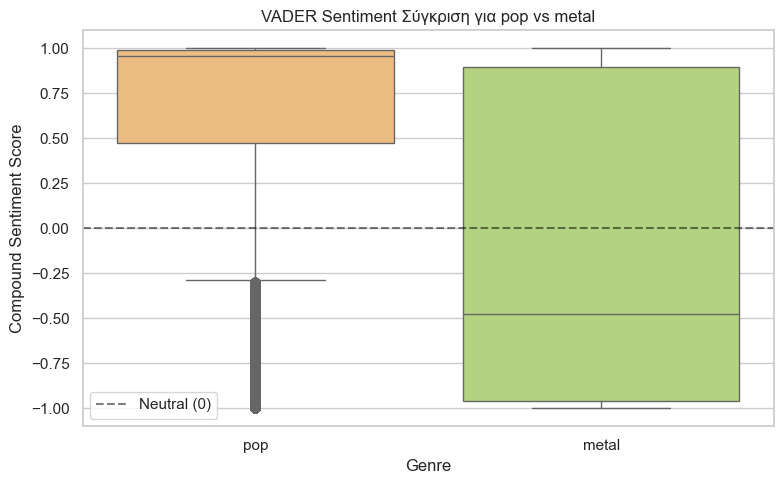

       count  mean  median
genre                     
metal    952 -0.13  -0.477
pop    20267  0.57   0.960


In [40]:
analyzer = SentimentIntensityAnalyzer()

# Compound score: +1 = πολύ θετικό, -1 = πολύ αρνητικό
df_merged['sentiment'] = df_merged['lyrics'].fillna('').apply(
    lambda x: analyzer.polarity_scores(x)['compound']
)

# Επιλογή 2 genres για καθαρή σύγκριση
genre1, genre2 = 'pop' , 'metal'
    
selected_genres = [genre1, genre2]

# Exploded view για sentiment ανά genre
df_merged_exploded = df_merged.explode('genre_list_unique').copy()
df_merged_exploded.rename(columns={'genre_list_unique': 'genre'}, inplace=True)

# Φίλτρο μόνο στα επιλεγμένα genres
df_sent = df_merged_exploded[df_merged_exploded['genre'].isin(selected_genres)].copy()

# Έλεγχος ότι υπάρχουν δεδομένα
available_genres = df_sent['genre'].unique().tolist()
print('Genres στο plot:', available_genres)

if len(df_sent) == 0:
    print('Δεν βρέθηκαν δεδομένα για τα επιλεγμένα genres.')
else:
    # Boxplot sentiment για τα 2 genres
    plt.figure(figsize=(8, 5))
    order = [g for g in selected_genres if g in available_genres]
    sns.boxplot(data=df_sent, x='genre', y='sentiment', hue='genre', order=order, palette='RdYlGn', legend=False)
    plt.axhline(0, color='black', linestyle='--', alpha=0.5, label='Neutral (0)')
    plt.title(f'VADER Sentiment Σύγκριση για {genre1} vs {genre2}')
    plt.xlabel('Genre')
    plt.ylabel('Compound Sentiment Score')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(df_sent.groupby('genre')['sentiment'].agg(['count', 'mean', 'median']).round(3))

Με βάση το γράφημα και τα στατιστικά, η υπόθεση επιβεβαιώνεται καθαρά στην περίπτωση της σύγκρισης pop με metal . Το pop έχει υψηλά θετικό κεντρικό σκορ (mean ≈ 0.57, median ≈ 0.96), ενώ το metal εμφανίζει αρνητική κεντρική τάση (mean ≈ -0.13, median ≈ -0.477). Άρα, στο συγκεκριμένο δείγμα, τα pop τραγούδια αποτιμώνται σαφώς πιο θετικά και τα metal πιο αρνητικά.

Παράλληλα, υπάρχουν δύο σημαντικές επιφυλάξεις: πρώτον, τα πλήθη είναι έντονα ανισομερή (pop: 20267 vs metal: 952), κάτι που μπορεί να επηρεάζει τη σταθερότητα της σύγκρισης. Δεύτερον, το VADER είναι λεξικοκεντρικό εργαλείο και δεν συλλαμβάνει πάντα πλήρως το μουσικό/ποιητικό context των στίχων (ειρωνεία, μεταφορές, πολυσημία). Επομένως, το αποτέλεσμα είναι ισχυρή ένδειξη, αλλά όχι απόλυτη απόδειξη.

### 3.8 Dimensionality Reduction — t-SNE Visualization

Εφαρμόζουμε t-SNE για να μειώσουμε τα embeddings σε 2D και να δούμε αν τα genres σχηματίζουν διακριτές συστάδες.  
Συγκρίνουμε **Audio** vs **Text** embeddings — ποια modality διαχωρίζει καλύτερα τις κλάσεις;

In [41]:
# t-SNE σε υποσύνολο για ταχύτητα (αν το dataset είναι μεγάλο)
N_SAMPLE = min(3000, len(df_merged))
idx = np.random.RandomState(SEED).choice(len(df_merged), N_SAMPLE, replace=False)

X_audio_sample = X_audio_pca[idx]
X_text_sample  = X_text[idx]
genres_sample  = df_merged['genre_list_unique'].iloc[idx].tolist()

print(f'Υποσύνολο για t-SNE: {N_SAMPLE} τραγούδια')

Υποσύνολο για t-SNE: 3000 τραγούδια


In [42]:
# t-SNE για Audio
tsne = TSNE(n_components=2, perplexity=40, random_state=SEED, max_iter=1000)
audio_2d = tsne.fit_transform(X_audio_sample)
print('Audio t-SNE done.')

Audio t-SNE done.


In [43]:
# t-SNE για Text
tsne2 = TSNE(n_components=2, perplexity=40, random_state=SEED, max_iter=1000)
text_2d = tsne2.fit_transform(X_text_sample)
print('Text t-SNE done.')

Text t-SNE done.


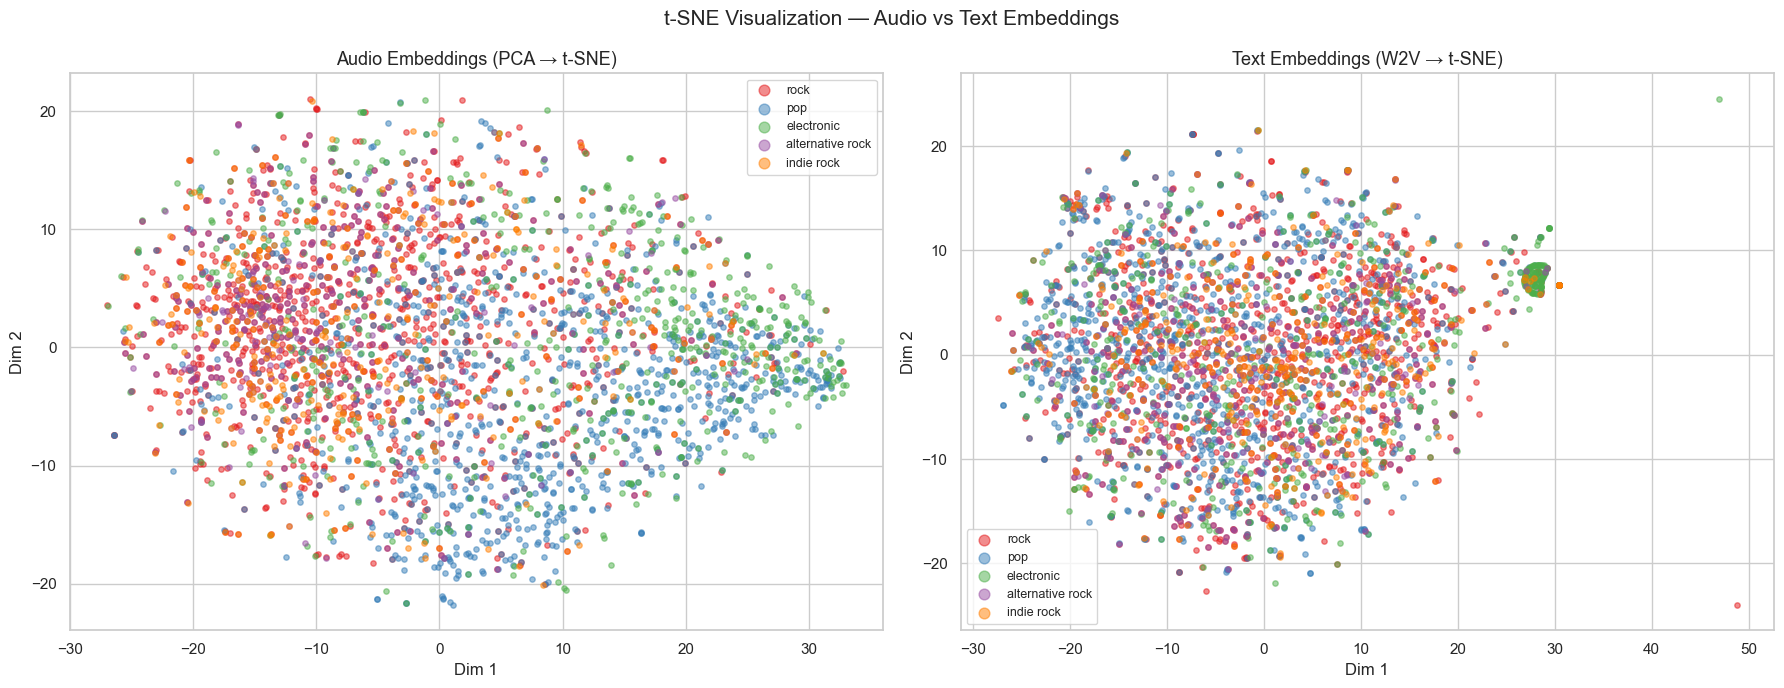

In [44]:
palette = sns.color_palette('Set1', n_colors=len(top5_genres))
genre_color = {g: palette[i] for i, g in enumerate(top5_genres)}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, data_2d, title in zip(axes,
                               [audio_2d, text_2d],
                               ['Audio Embeddings (PCA → t-SNE)', 'Text Embeddings (W2V → t-SNE)']):
    for genre in top5_genres:
        mask = np.array([genre in genres for genres in genres_sample])
        ax.scatter(data_2d[mask, 0], data_2d[mask, 1],
                   c=[genre_color[genre]], label=genre, alpha=0.5, s=15)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')
    ax.legend(markerscale=2, fontsize=9)

plt.suptitle('t-SNE Visualization — Audio vs Text Embeddings', fontsize=15)
plt.tight_layout()
plt.show()

Στα 2D plots φαίνονται τοπικές συστάδες, αλλά όχι καθαρός παγκόσμιος διαχωρισμός των genres. Υπάρχει σημαντική επικάλυψη μεταξύ των περισσότερων κλάσεων και στα δύο modalities, κάτι αναμενόμενο αφού πολλά τραγούδια έχουν υβριδικό χαρακτήρα και κοινά στοιχεία.

Στο Audio (PCA→t-SNE) η δομή φαίνεται ελαφρώς πιο οργανωμένη, με περιοχές όπου κάποια genres συγκεντρώνονται περισσότερο και σχηματίζουν σχετικά πιο διακριτές “ζώνες”, παρότι παραμένει ανάμειξη.

Στο Text (W2V→t-SNE) ο κεντρικός χώρος είναι πιο ανακατεμένος, με μικρότερη συνολική διαχωρισιμότητα, αν και εμφανίζονται μικρές συμπαγείς νησίδες που πιθανόν αντιστοιχούν σε υποομάδες με πολύ παρόμοιο λεξιλόγιο.

Συμπέρασμα: και οι δύο αναπαραστάσεις έχουν πληροφορία, αλλά στο συγκεκριμένο plot το Audio modality φαίνεται να διαχωρίζει ελαφρώς καλύτερα τις κλάσεις από το Text.

### 3.9 Similarity Analysis — Cosine Similarity

Δοθέντος ενός τραγουδιού, βρίσκουμε τα 5 πιο «όμοια» τραγούδια:  
- Πρώτα βάσει **στίχων** (Text Embeddings)
- Μετά βάσει **ήχου** (Audio Embeddings)

Η Cosine Similarity μετράει τη γωνία μεταξύ δύο διανυσμάτων — τιμές κοντά στο 1 σημαίνουν μεγάλη ομοιότητα.

In [45]:
def find_similar_songs(query_idx, embeddings, df, top_n=5):
    """Βρίσκει τα top_n πιο όμοια τραγούδια βάσει cosine similarity."""
    query_vec = embeddings[query_idx].reshape(1, -1)
    sims = cosine_similarity(query_vec, embeddings)[0]
    sims[query_idx] = -1  # εξαίρεση του ίδιου τραγουδιού
    top_indices = np.argsort(sims)[::-1][:top_n]
    results = df.iloc[top_indices][['id', 'genre_list_unique']].copy()
    results.rename(columns={'genre_list_unique': 'genres'}, inplace=True)
    results['cosine_similarity'] = sims[top_indices].round(4)
    return results

# Επιλογή τυχαίου τραγουδιού-ερωτήματος
query_idx = 0
query_song = df_merged.iloc[query_idx]
print(f"Query song — ID: {query_song['id']}, Genres: {query_song['genre_list_unique']}")
print()

Query song — ID: 0009fFIM1eYThaPg, Genres: ['pop']



In [46]:
print('=== Top-5 Όμοια βάσει ΣΤΙΧΩΝ (Text Embeddings) ===')
display(find_similar_songs(query_idx, X_text, df_merged))

print('\n=== Top-5 Όμοια βάσει ΗΧΟΥ (Audio Embeddings) ===')
display(find_similar_songs(query_idx, X_audio_pca, df_merged))

=== Top-5 Όμοια βάσει ΣΤΙΧΩΝ (Text Embeddings) ===


,id,genres,cosine_similarity
10703,Bp2C0upIsbgDIj6g,[pop],0.9451
47064,pxgFoLb5tSjKO0Rr,"[soul, pop]",0.9367
44652,nMWxakz2ha5Qtlk8,"[rock, turkish rock]",0.9218
15582,HFLuvJXc6SjcJt7d,[pop],0.9090
9242,ADoeKL7oT9iBfak3,"[pop, electronic]",0.9068



=== Top-5 Όμοια βάσει ΗΧΟΥ (Audio Embeddings) ===


,id,genres,cosine_similarity
50005,tFGgxBWeAQKBRKO8,"[pop, samba]",0.6054
18686,Ke7XhgSrvYsGgyNQ,[pop],0.5928
43105,ldBzhsxpTWmOaBeN,"[house, electronic]",0.5715
859,0veCOsDkANplSblN,"[trance, progressive trance, electronic]",0.5599
7898,8iWQVzIeyvNMAllZ,"[indietronica, electronic, electropop, experim...",0.5472


Η σύγκριση δείχνει ξεκάθαρα ότι οι δύο λίστες “όμοιων” τραγουδιών αποτυπώνουν διαφορετικό τύπο ομοιότητας.

Στη λίστα βάσει στίχων (Text Embeddings) οι cosine τιμές είναι πολύ υψηλές (~0.91–0.95), άρα τα τραγούδια που επιστρέφονται έχουν πολύ κοντινό λεξιλόγιο/θεματική. Αυτό φαίνεται και από τα genres που επαναλαμβάνονται γύρω από pop και συγγενείς λεκτικές εκφράσεις, ακόμα και όταν εμφανίζεται ένα rock entry, γιατί η ομοιότητα κρίνεται από το κείμενο και όχι από το ηχητικό ύφος.

Αντίθετα, στη λίστα βάσει ήχου (Audio Embeddings) οι τιμές είναι χαμηλότερες (~0.55–0.61) και οι προτεινόμενοι neighbors κινούνται σε πιο “ηχητικές” οικογένειες (π.χ. house/trance/electronic/pop samba). Δηλαδή, εδώ η ομοιότητα σχετίζεται με timbre/ρυθμική υφή/παραγωγή (MFCC στατιστικά), όχι με το τι λένε οι στίχοι.

Άρα οι λίστες διαφέρουν επειδή μετρούν διαφορετική πληροφορία:

Text → σημασιολογική/θεματική ομοιότητα στίχων

Audio → ακουστική/μορφολογική ομοιότητα ήχου

Αυτό ακριβώς υποστηρίζει την πολυτροπική λογική: ένα τραγούδι μπορεί να είναι “κοντά” σε άλλα λυρικά αλλά “μακριά” ηχητικά (ή το αντίστροφο).